# Task 4 — Notebook 01: Feature Panel Construction and EDA

**Goal:** Build the rolling feature matrix for crop-type classification using CDL history features, NDVI phenology statistics, and SMAP soil-moisture aggregates. Explore feature distributions, class balance, rotation regimes, and missing-data patterns.

**Data sources:**
- `data/processed/cdl/cdl_stack_wide.parquet` (2008–2025, columns: iy, ix, cdl_YYYY)
- `data/processed/ndvi/ndvi_weekly_{year}_wide.parquet` + `*_metadata.json` (2008–2025)
- `data/processed/smap/smap_weekly_{year}_wide.parquet` + `*_metadata.json` (2015–2025)

**Note:** `cdl_stack_spatial_metadata.json` is not shipped with the processed data. Grid dimensions (height, width) and CRS/transform are derived automatically from the CDL parquet and NDVI metadata at first run and cached as a sidecar JSON.

**Outputs:**
- `data/processed/task4/feature_matrix_panel.parquet` — training + validation panel (2013–2022)
- `data/processed/task4/test_frame_2023.parquet` — test-year feature frame
- EDA figures under `artifacts/figures/task4/`

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "task4_crop_mapping.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

FIGURES_DIR = REPO_ROOT / cfg["output"]["figures_dir"]
TABLES_DIR = REPO_ROOT / cfg["output"]["tables_dir"]
PROCESSED_DIR = REPO_ROOT / cfg["output"]["processed_dir"]
for d in (FIGURES_DIR, TABLES_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = cfg["run"]["seed"]
np.random.seed(SEED)

CLASS_NAMES = ["other_cropland", "corn", "soybean", "winter_wheat"]

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"Seed: {SEED}")

REPO_ROOT: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling
Seed: 42


In [2]:
from src.preprocessing.task4_panel import load_grid_meta

grid_meta = load_grid_meta(REPO_ROOT)
print(f"Grid: {grid_meta['height']} x {grid_meta['width']}")
print(f"CRS:  {grid_meta.get('crs', 'N/A')}")
print(f"CDL years available: {grid_meta.get('years', 'N/A')}")

Grid: 2960 x 4096
CRS:  EPSG:5070
CDL years available: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Assemble the Training + Validation Panel (2013–2022)

This calls `assemble_training_panel` from `src.preprocessing.task4_panel`, which for each year:
1. Builds a cropland mask (pixels with ≥3 cropland years)
2. Computes CDL history features: lag codes, transition counts, time-since, fraction, run length, alternation score, pattern distance, sequence entropy, 3×3 neighbourhood fractions, rotation regime
3. Joins NDVI phenology features: base, peak, amplitude, mean, integral, peak week, greenup week/slope, seasonal means, historical variability
4. Joins SMAP growing-season features: mean soil moisture, spring SM, wet/dry week fractions
5. Maps CDL codes to model labels: 0=other, 1=corn, 2=soy, 3=winter_wheat

In [3]:
from src.preprocessing.task4_panel import (
    assemble_training_panel,
    build_test_year_frame,
    train_val_test_split,
)

In [ ]:


panel_path = PROCESSED_DIR / "feature_matrix_panel.parquet"

if panel_path.is_file():
    print(f"Loading existing panel from {panel_path}")
    panel = pd.read_parquet(panel_path)
else:
    print("Building training panel (this may take a while)...")
    panel = assemble_training_panel(REPO_ROOT, cfg, save_path=panel_path)

print(f"Panel shape: {panel.shape}")
print(f"Columns ({len(panel.columns)}): {list(panel.columns)}")
print(f"Years: {sorted(panel['year'].unique())}")
print(f"Memory usage: {panel.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Building training panel (this may take a while)...


Building training panel:   0%|          | 0/10 [00:00<?, ?yr/s]

/Users/buttz/Desktop/projects/GeoCrop-Spatiotemporal-Modeling/src/preprocessing/task4_panel.py:401: RuntimeWarning: Mean of empty slice
  "ndvi_peak_hist_mean": np.nanmean(hist_peak, axis=1).astype(np.float32),
/Users/buttz/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/buttz/Desktop/projects/GeoCrop-Spatiotemporal-Modeling/src/preprocessing/task4_panel.py:403: RuntimeWarning: Mean of empty slice
  "ndvi_peak_week_hist_mean": np.nanmean(hist_peak_week, axis=1).astype(np.float32),
/Users/buttz/Desktop/projects/GeoCrop-Spatiotemporal-Modeling/src/preprocessing/task4_panel.py:401: RuntimeWarning: Mean of empty slice
  "ndvi_peak_hist_mean": np.nanmean(hist_peak, axis=1).astype(np.float32),
/Users/buttz/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 

Panel shape: (5000000, 43)
Columns (43): ['iy', 'ix', 'cdl_t1', 'cdl_t2', 'cdl_t3', 'cdl_t4', 'cdl_t5', 'n_corn_to_soy', 'n_soy_to_corn', 'n_corn_corn', 'n_soy_soy', 'time_since_last_corn', 'time_since_last_soy', 'frac_years_corn', 'frac_years_soy', 'max_run_length', 'alternation_score', 'pattern_distance', 'sequence_entropy', 'neigh_frac_corn', 'neigh_frac_soy', 'rotation_regime', 'label', 'year', 'ndvi_base', 'ndvi_peak', 'ndvi_amplitude', 'ndvi_mean', 'ndvi_integral', 'ndvi_peak_week', 'ndvi_greenup_week', 'ndvi_greenup_slope', 'ndvi_early_mean', 'ndvi_mid_mean', 'ndvi_late_mean', 'smap_mean_gs', 'smap_spring_sm', 'smap_pct_wet_weeks', 'smap_pct_dry_weeks', 'ndvi_peak_hist_mean', 'ndvi_peak_hist_std', 'ndvi_peak_week_hist_mean', 'ndvi_peak_week_hist_std']
Years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
Memory usage: 1.15 GB


In [4]:
panel = pd.read_parquet('../../data/processed/task4/feature_matrix_panel.parquet')

In [5]:
test_path = PROCESSED_DIR / "test_frame_2023.parquet"
test_year = int(cfg["panel"]["test_year"])

if test_path.is_file():
    print(f"Loading existing test frame from {test_path}")
    test_df = pd.read_parquet(test_path)
else:
    print(f"Building test frame for year {test_year}...")
    test_df = build_test_year_frame(REPO_ROOT, cfg, test_year)
    test_df.to_parquet(test_path, index=False, compression="zstd")

print(f"Test frame shape: {test_df.shape}")
print(f"Test year: {test_df['year'].unique()}")

Building test frame for year 2023...


Test year 2023:   0%|          | 0/5 [00:00<?, ?step/s]

c:\Users\sardo\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:355: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(M, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:357: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:371: RuntimeWarning: All-NaN slice encountered
  greenup_slope = np.nanmax(inc, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:380: RuntimeWarning: Mean of empty slice
  early = np.nanmean(M[:, i0:i1], axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Mode

NDVI history (test year):   0%|          | 0/10 [00:00<?, ?yr/s]

c:\Users\sardo\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:355: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(M, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:357: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(M, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:371: RuntimeWarning: All-NaN slice encountered
  greenup_slope = np.nanmax(inc, axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\src\preprocessing\task4_panel.py:380: RuntimeWarning: Mean of empty slice
  early = np.nanmean(M[:, i0:i1], axis=1)
C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Mode

Test frame shape: (500000, 43)
Test year: [2023]


## 2. Class Distribution

Examine the balance of crop-type labels across training years.

Class counts per year:


,other_cropland,corn,soybean,winter_wheat
year,,,,
2013,125000,125000,125000,125000
2014,125000,125000,125000,125000
2015,125000,125000,125000,125000
2016,125000,125000,125000,125000
2017,125000,125000,125000,125000
2018,125000,125000,125000,125000
2019,125000,125000,125000,125000
2020,125000,125000,125000,125000
2021,125000,125000,125000,125000


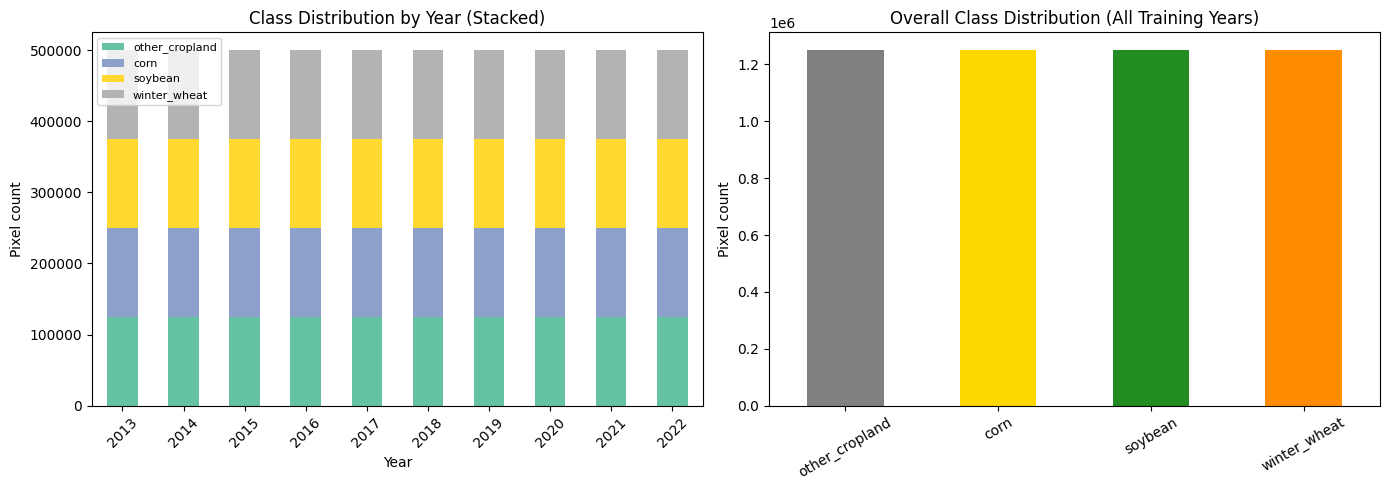


Overall class proportions:
  other_cropland: 25.000%
  corn: 25.000%
  soybean: 25.000%
  winter_wheat: 25.000%


In [6]:
valid_panel = panel[np.isfinite(panel["label"])].copy()
valid_panel["label_int"] = valid_panel["label"].astype(int)

class_counts = valid_panel.groupby(["year", "label_int"]).size().unstack(fill_value=0)
class_counts.columns = [CLASS_NAMES[int(c)] for c in class_counts.columns]

print("Class counts per year:")
display(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Class Distribution by Year (Stacked)")
axes[0].set_ylabel("Pixel count")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper left", fontsize=8)

overall = valid_panel["label_int"].value_counts().sort_index()
overall.index = [CLASS_NAMES[i] for i in overall.index]
overall.plot(kind="bar", ax=axes[1], color=["gray", "#FFD700", "#228B22", "#FF8C00"])
axes[1].set_title("Overall Class Distribution (All Training Years)")
axes[1].set_ylabel("Pixel count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nOverall class proportions:")
props = valid_panel["label_int"].value_counts(normalize=True).sort_index()
for i, p in props.items():
    print(f"  {CLASS_NAMES[int(i)]}: {p:.3%}")

## 3. Rotation Regime Distribution

The panel includes a `rotation_regime` column classifying each pixel's historical cropping pattern as **regular** (consistent corn–soy alternation), **monoculture** (dominated by one crop), or **irregular** (neither).

Rotation regime counts per year:


rotation_regime,irregular,monoculture,regular
year,,,
2013,356968,50988,92044
2014,373242,33957,92801
2015,277552,133942,88506
2016,255614,160985,83401
2017,260855,161411,77734
2018,255150,159199,85651
2019,258868,153499,87633
2020,291867,127224,80909
2021,298541,126200,75259


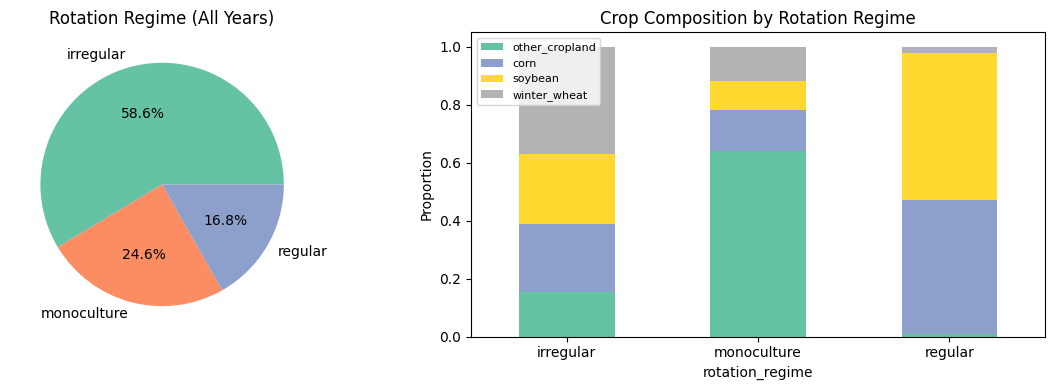

In [7]:
if "rotation_regime" in valid_panel.columns:
    regime_counts = valid_panel.groupby(["year", "rotation_regime"]).size().unstack(fill_value=0)
    print("Rotation regime counts per year:")
    display(regime_counts)

    overall_regime = valid_panel["rotation_regime"].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    overall_regime.plot(kind="pie", ax=axes[0], autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62", "#8da0cb"])
    axes[0].set_title("Rotation Regime (All Years)")
    axes[0].set_ylabel("")

    cross = pd.crosstab(valid_panel["rotation_regime"], valid_panel["label_int"])
    cross.columns = [CLASS_NAMES[int(c)] for c in cross.columns]
    cross_pct = cross.div(cross.sum(axis=1), axis=0)
    cross_pct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
    axes[1].set_title("Crop Composition by Rotation Regime")
    axes[1].set_ylabel("Proportion")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_rotation_regimes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("rotation_regime column not found in panel.")

## 4. Feature Summary and Missing Values

Number of numeric features: 38
Features: ['cdl_t1', 'cdl_t2', 'cdl_t3', 'cdl_t4', 'cdl_t5', 'n_corn_to_soy', 'n_soy_to_corn', 'n_corn_corn', 'n_soy_soy', 'time_since_last_corn', 'time_since_last_soy', 'frac_years_corn', 'frac_years_soy', 'max_run_length', 'alternation_score', 'pattern_distance', 'sequence_entropy', 'neigh_frac_corn', 'neigh_frac_soy', 'ndvi_base', 'ndvi_peak', 'ndvi_amplitude', 'ndvi_mean', 'ndvi_integral', 'ndvi_peak_week', 'ndvi_greenup_week', 'ndvi_greenup_slope', 'ndvi_early_mean', 'ndvi_mid_mean', 'ndvi_late_mean', 'smap_mean_gs', 'smap_spring_sm', 'smap_pct_wet_weeks', 'smap_pct_dry_weeks', 'ndvi_peak_hist_mean', 'ndvi_peak_hist_std', 'ndvi_peak_week_hist_mean', 'ndvi_peak_week_hist_std']

Features with missing values:
  ndvi_peak_week_hist_mean: 88.35%
  ndvi_peak_week_hist_std: 88.35%
  ndvi_peak_hist_mean: 88.35%
  ndvi_peak_hist_std: 88.35%
  smap_mean_gs: 86.60%
  smap_spring_sm: 86.60%
  time_since_last_soy: 49.27%
  time_since_last_corn: 43.40%
  smap_pct_

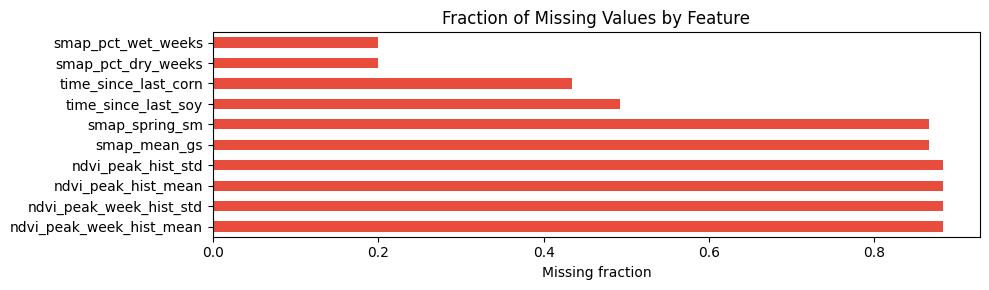

In [8]:
drop_cols = {"iy", "ix", "year", "label", "rotation_regime", "label_int"}
feature_cols = [c for c in valid_panel.columns if c not in drop_cols
                and not pd.api.types.is_object_dtype(valid_panel[c])]

print(f"Number of numeric features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

missing_pct = valid_panel[feature_cols].isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    print("\nFeatures with missing values:")
    for feat, pct in missing_pct.items():
        print(f"  {feat}: {pct:.2%}")

    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_pct) * 0.3)))
    missing_pct.plot(kind="barh", ax=ax, color="#e74c3c")
    ax.set_title("Fraction of Missing Values by Feature")
    ax.set_xlabel("Missing fraction")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_missing_values.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("\nNo missing values in feature columns.")

## 5. Feature Distributions by Crop Type

Violin plots of key features stratified by crop label, on a random sample for performance.

C:\Users\sardo\AppData\Local\Temp\ipykernel_15804\2477364312.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=15)
C:\Users\sardo\AppData\Local\Temp\ipykernel_15804\2477364312.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=15)
C:\Users\sardo\AppData\Local\Temp\ipykernel_15804\2477364312.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=15)
C:\Users\sardo\AppData\Local\Temp\ipykernel_15804\2477364312.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, fonts

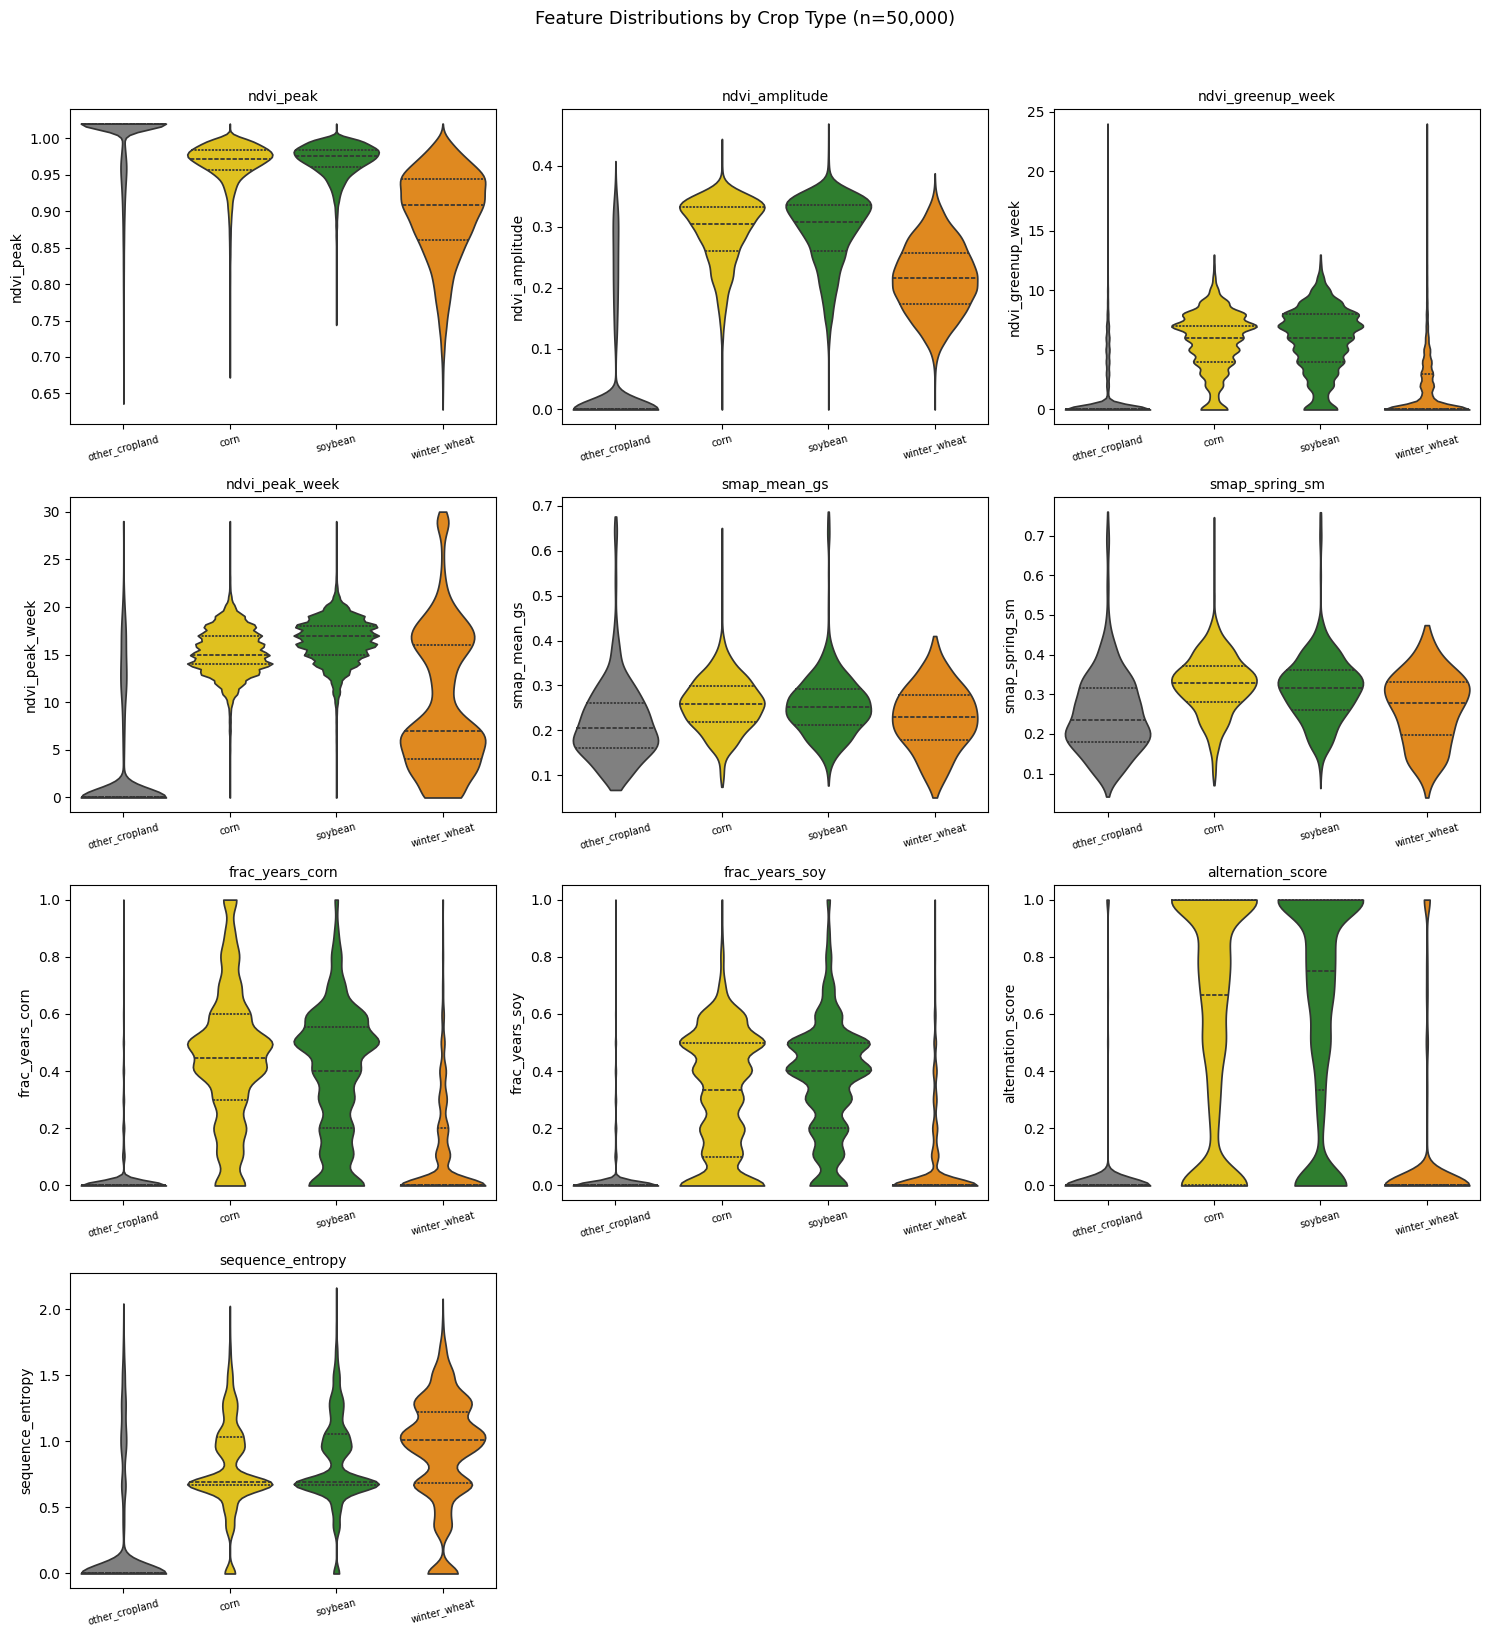

In [9]:
SAMPLE_N = min(50_000, len(valid_panel))
sample = valid_panel.sample(n=SAMPLE_N, random_state=SEED)

key_features = [
    c for c in ["ndvi_peak", "ndvi_amplitude", "ndvi_greenup_week", "ndvi_peak_week",
                "smap_mean_gs", "smap_spring_sm",
                "frac_years_corn", "frac_years_soy", "alternation_score", "sequence_entropy"]
    if c in sample.columns
]

if key_features:
    n_feats = len(key_features)
    n_cols = 3
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for idx, feat in enumerate(key_features):
        ax = axes[idx]
        sns.violinplot(
            data=sample, x="label_int", y=feat, ax=ax,
            palette=["gray", "#FFD700", "#228B22", "#FF8C00"],
            inner="quartile", cut=0, density_norm="width",
        )
        ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=15)
        ax.set_xlabel("")
        ax.set_title(feat, fontsize=10)

    for idx in range(n_feats, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f"Feature Distributions by Crop Type (n={SAMPLE_N:,})", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_feature_violins.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Key features not found in panel.")

## 6. Feature Correlation Heatmap

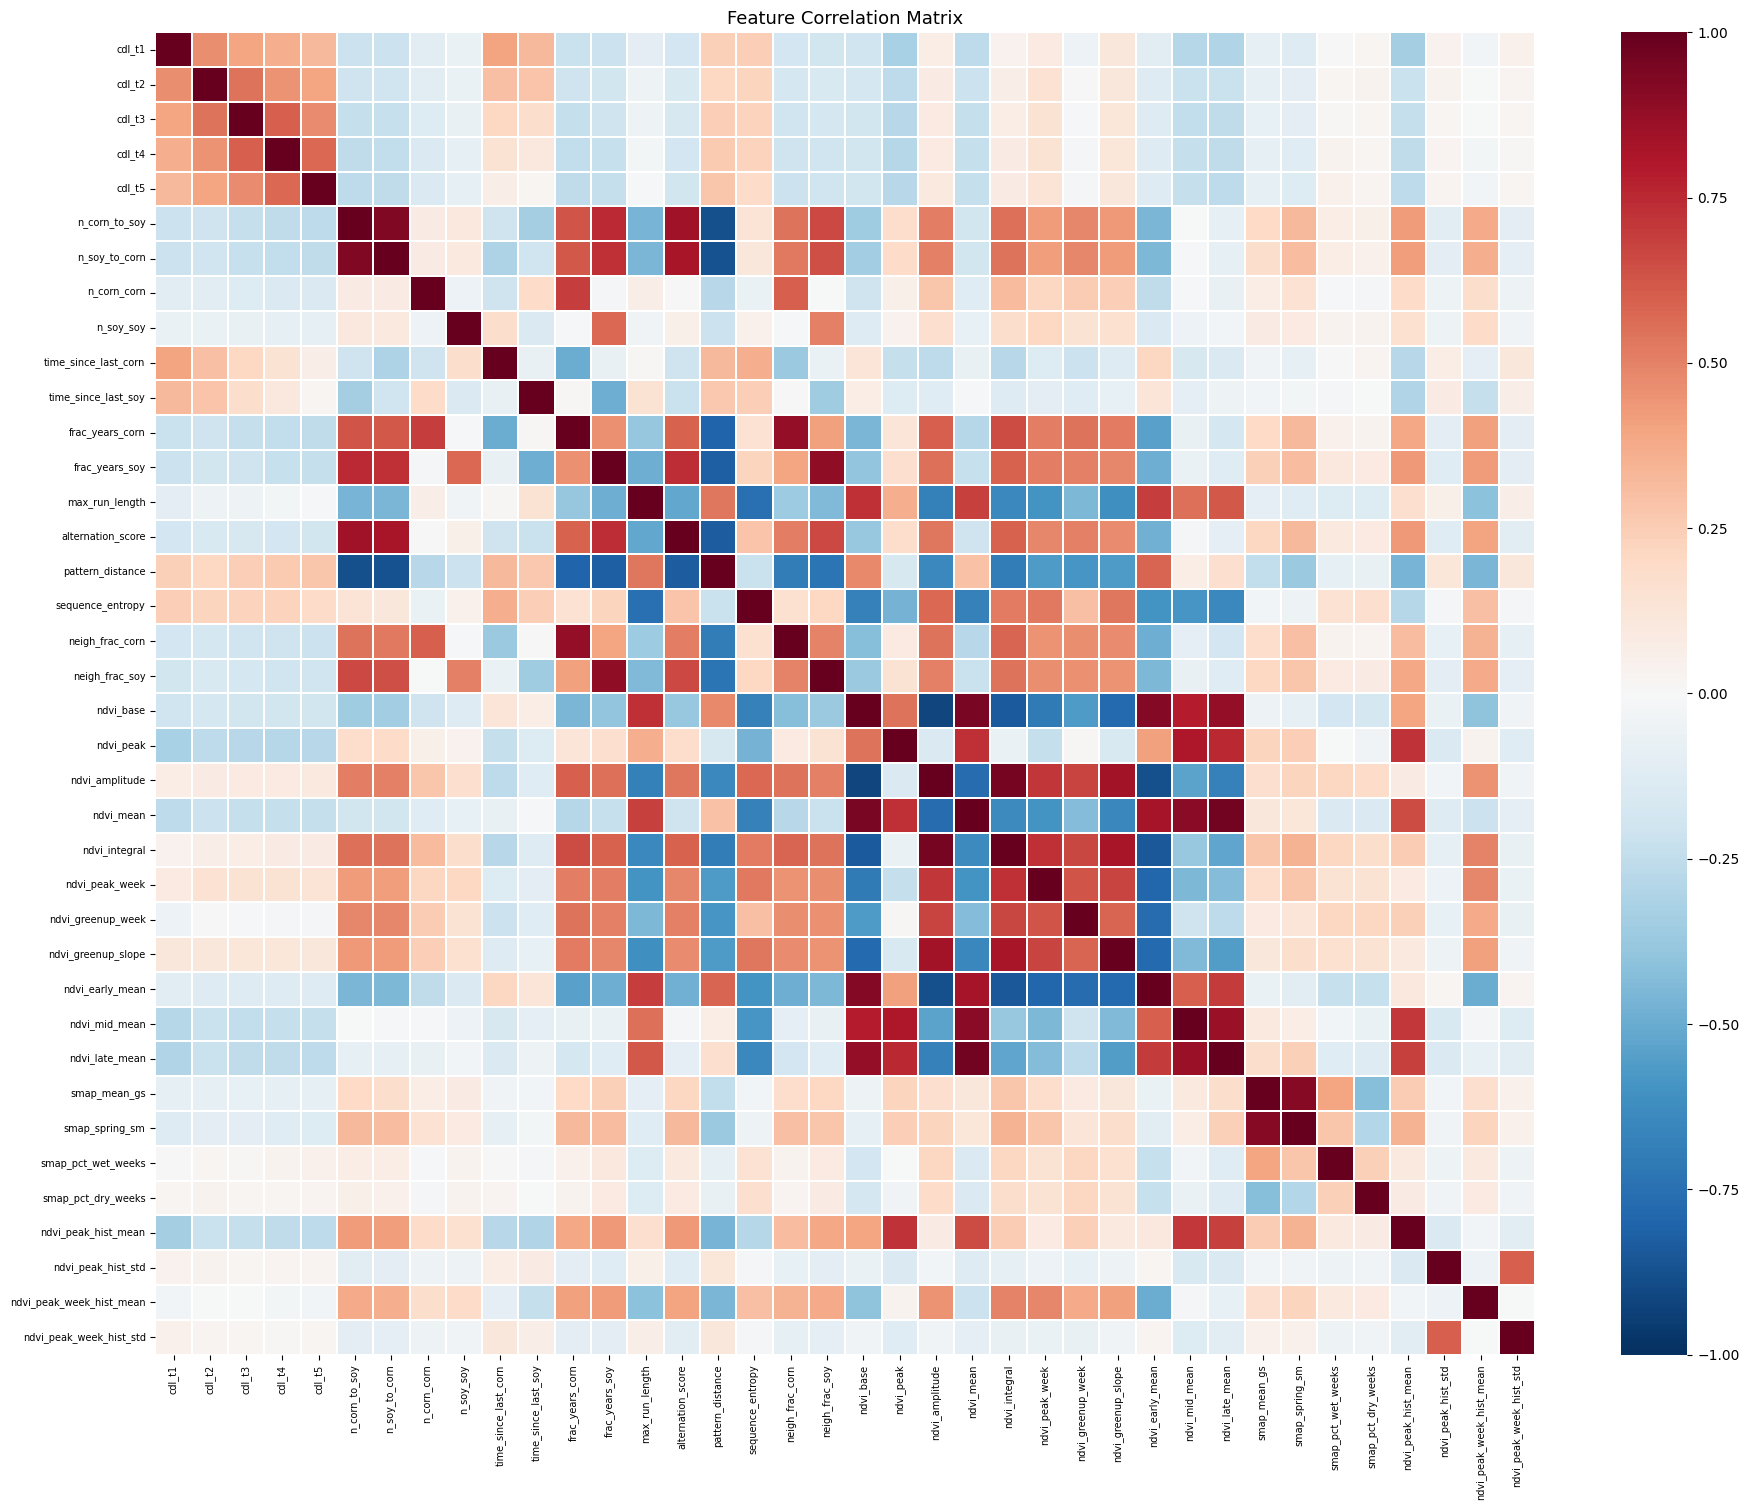

In [10]:
corr_features = [c for c in feature_cols if c in sample.columns]

if len(corr_features) > 1:
    corr = sample[corr_features].corr()
    fig, ax = plt.subplots(figsize=(max(10, len(corr_features) * 0.5),
                                    max(8, len(corr_features) * 0.4)))
    sns.heatmap(
        corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        xticklabels=True, yticklabels=True,
        linewidths=0.3, fmt=".1f",
        annot=len(corr_features) <= 20,
    )
    ax.set_title("Feature Correlation Matrix", fontsize=13)
    ax.tick_params(axis="both", labelsize=7)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_feature_correlation.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Train / Validation / Test Split Summary

In [11]:
train_df, val_df = train_val_test_split(panel, cfg)
train_df = train_df[np.isfinite(train_df["label"])].copy()
val_df = val_df[np.isfinite(val_df["label"])].copy()
test_valid = test_df[np.isfinite(test_df["label"])].copy()

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Years": [
        f"{train_df['year'].min()}–{train_df['year'].max()}",
        str(val_df["year"].iloc[0]),
        str(test_valid["year"].iloc[0]),
    ],
    "N_pixels": [len(train_df), len(val_df), len(test_valid)],
})

for lbl, name in enumerate(CLASS_NAMES):
    split_summary[name] = [
        (train_df["label"] == lbl).sum(),
        (val_df["label"] == lbl).sum(),
        (test_valid["label"] == lbl).sum(),
    ]

display(split_summary)
split_summary.to_csv(TABLES_DIR / "task4_split_summary.csv", index=False)
print(f"Wrote {TABLES_DIR / 'task4_split_summary.csv'}")

,Split,Years,N_pixels,other_cropland,corn,soybean,winter_wheat
0,Train,2013–2021,4500000,1125000,1125000,1125000,1125000
1,Validation,2022,500000,125000,125000,125000,125000
2,Test,2023,500000,125000,125000,125000,125000


Wrote C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\tables\task4\task4_split_summary.csv


## Summary

The rolling feature panel has been constructed with:
- **CDL history features:** lag codes, transition counts, time-since-last-crop, crop fractions, run length, alternation score, pattern distance, sequence entropy, neighbourhood fractions
- **NDVI phenology features:** base, peak, amplitude, mean, integral, peak week, greenup timing/slope, seasonal sub-means, historical variability
- **SMAP soil moisture features:** growing-season mean, spring moisture, wet/dry week fractions

**Key observations** from the EDA:
- Class imbalance is expected — corn and soybean dominate; winter wheat and other cropland are minority classes. The `is_unbalance` flag in LightGBM config addresses this.
- NDVI and SMAP features show clear separability between crop types (visible in violin plots), suggesting they will add value over CDL-only baselines.
- SMAP features have missing values for years before 2015 (mission launch), handled as NaN by the model.

**Next:** Notebook 02 trains LightGBM under ablation configurations and quantifies feature value-add.